# PET MLEM Reconstruction

This notebook demonstrates Maximum Likelihood Expectation Maximization (MLEM) reconstruction for Positron Emission Tomography (PET).

## Measurement Model

PET data follows **Poisson statistics** (photon counting):

$$y_i \sim \text{Poisson}\!\left(\sum_j A_{ij} x_j + r_i\right)$$

This is fundamentally different from CT/MRI (Gaussian noise). The MLEM algorithm maximizes the Poisson log-likelihood via **multiplicative** updates:

$$x_j^{(k+1)} = \frac{x_j^{(k)}}{\sum_i A_{ij}} \sum_i A_{ij} \frac{y_i}{\sum_{j'} A_{ij'} x_{j'}^{(k)} + r_i}$$

In [1]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt

TASK_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, TASK_DIR)

%matplotlib inline

## 1. Load Data

In [2]:
from src.preprocessing import load_sinogram_data, load_ground_truth, load_metadata, preprocess_sinogram

sinogram, background, theta = load_sinogram_data(TASK_DIR)
activity_gt = load_ground_truth(TASK_DIR)
meta = load_metadata(TASK_DIR)

# Squeeze batch dimension from theta for use with solvers
theta = theta.squeeze(0)

print(f"Image size: {meta['image_size']}x{meta['image_size']}")
print(f"Sinogram: {sinogram.shape}")
print(f"Angles: {meta['n_angles']}")
print(f"Count level: {meta['count_level']}")
print(f"Noise model: {meta['noise_model']}")
print(f"Randoms fraction: {meta['randoms_fraction']}")

Image size: 128x128
Sinogram: (1, 128, 120)
Angles: 120
Count level: 1000.0
Noise model: poisson
Randoms fraction: 0.1


## 2. Ground Truth and Sinogram

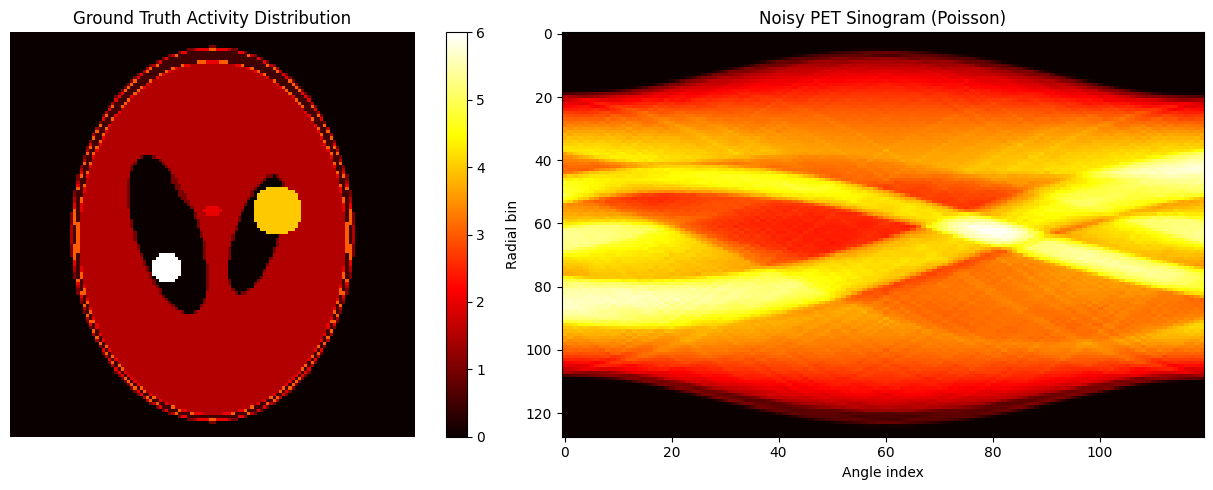

In [3]:
gt = activity_gt[0]
sino = preprocess_sinogram(sinogram)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(gt, cmap='hot', vmin=0)
axes[0].set_title('Ground Truth Activity Distribution')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

axes[1].imshow(sino, aspect='auto', cmap='hot')
axes[1].set_title('Noisy PET Sinogram (Poisson)')
axes[1].set_xlabel('Angle index')
axes[1].set_ylabel('Radial bin')

plt.tight_layout()
plt.show()

## 3. Poisson Noise Characteristics

PET noise has variance proportional to the mean (Poisson): regions with higher activity have higher absolute noise but lower relative noise.

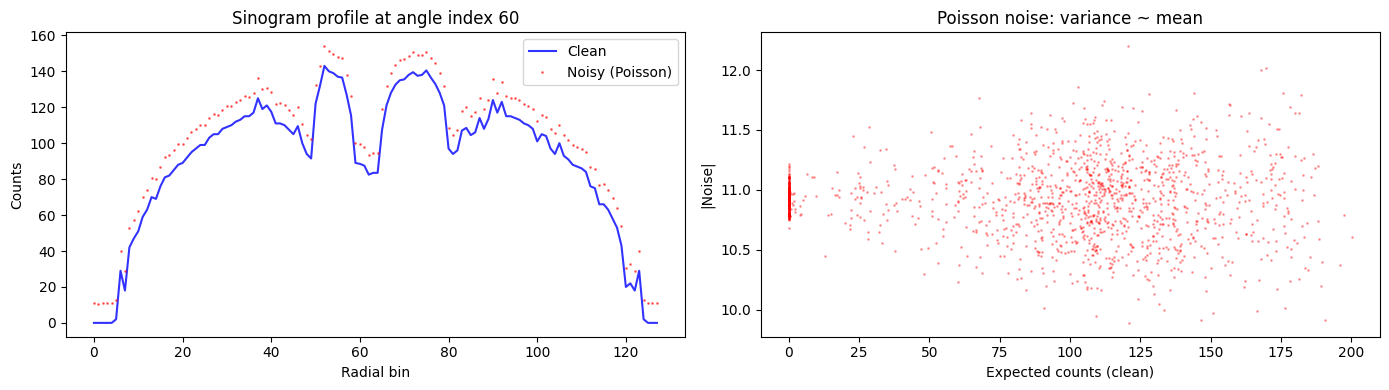

In [4]:
from src.physics_model import pet_forward_project

# Compare clean vs noisy sinogram profiles
sino_clean = pet_forward_project(gt, theta)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mid_angle = sino.shape[1] // 2
axes[0].plot(sino_clean[:, mid_angle], 'b-', label='Clean', alpha=0.8)
axes[0].plot(sino[:, mid_angle], 'r.', markersize=2, label='Noisy (Poisson)', alpha=0.5)
axes[0].set_xlabel('Radial bin')
axes[0].set_ylabel('Counts')
axes[0].set_title(f'Sinogram profile at angle index {mid_angle}')
axes[0].legend()

# Show noise is signal-dependent
noise = sino - sino_clean
axes[1].scatter(sino_clean.ravel()[::10], np.abs(noise.ravel()[::10]),
                s=1, alpha=0.3, c='red')
axes[1].set_xlabel('Expected counts (clean)')
axes[1].set_ylabel('|Noise|')
axes[1].set_title('Poisson noise: variance ~ mean')

plt.tight_layout()
plt.show()

## 4. Precomputed Reconstructions

In [5]:
ref_dir = os.path.join(TASK_DIR, 'evaluation', 'reference_outputs')

mlem_data = np.load(os.path.join(ref_dir, 'recon_mlem.npz'))
osem_data = np.load(os.path.join(ref_dir, 'recon_osem.npz'))

recon_mlem = mlem_data['reconstruction'][0]
recon_osem = osem_data['reconstruction'][0]
ll_mlem = mlem_data['log_likelihood']
ll_osem = osem_data['log_likelihood']

## 5. MLEM vs OSEM Comparison

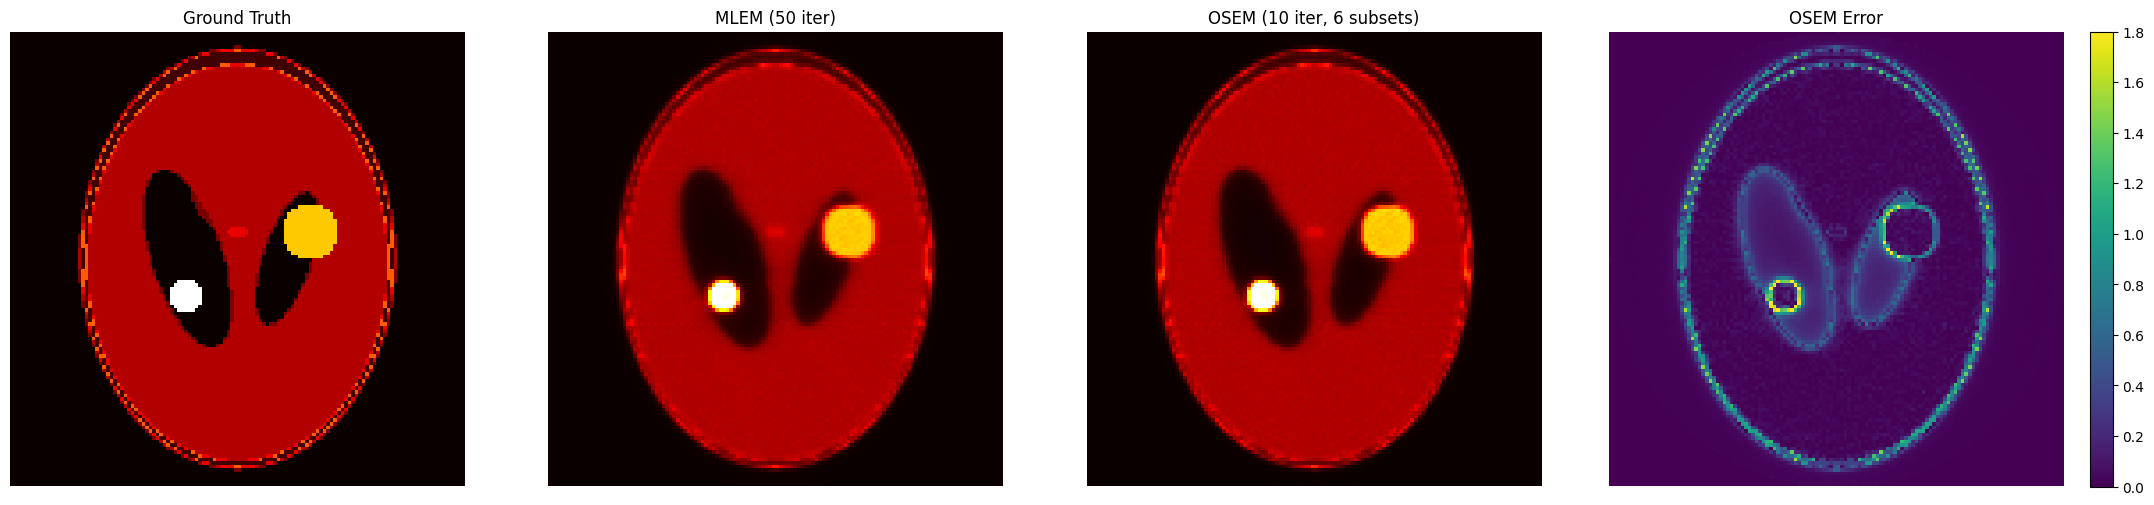

In [6]:
vmin, vmax = 0, gt.max()

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(gt, cmap='hot', vmin=vmin, vmax=vmax)
axes[0].set_title('Ground Truth')
axes[0].axis('off')

axes[1].imshow(recon_mlem, cmap='hot', vmin=vmin, vmax=vmax)
axes[1].set_title('MLEM (50 iter)')
axes[1].axis('off')

axes[2].imshow(recon_osem, cmap='hot', vmin=vmin, vmax=vmax)
axes[2].set_title('OSEM (10 iter, 6 subsets)')
axes[2].axis('off')

error = np.abs(recon_osem - gt)
im = axes[3].imshow(error, cmap='viridis', vmin=0, vmax=vmax*0.3)
axes[3].set_title('OSEM Error')
axes[3].axis('off')
plt.colorbar(im, ax=axes[3], fraction=0.046)

plt.tight_layout()
plt.show()

## 6. Convergence: Log-Likelihood

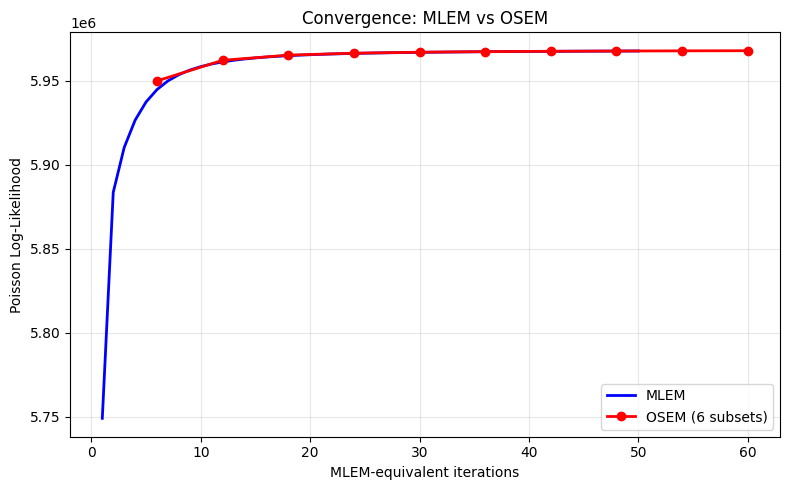

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(ll_mlem)+1), ll_mlem, 'b-', label='MLEM', linewidth=2)

# Scale OSEM iterations to equivalent MLEM iterations (* n_subsets)
osem_equiv_iters = np.arange(1, len(ll_osem)+1) * 6  # 6 subsets
ax.plot(osem_equiv_iters, ll_osem, 'r-o', label='OSEM (6 subsets)', linewidth=2)

ax.set_xlabel('MLEM-equivalent iterations')
ax.set_ylabel('Poisson Log-Likelihood')
ax.set_title('Convergence: MLEM vs OSEM')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Quantitative Metrics

In [8]:
with open(os.path.join(TASK_DIR, 'evaluation', 'metrics.json')) as f:
    metrics = json.load(f)

print("Method                                    | NCC    | NRMSE")
print("-" * 60)
for entry in metrics['baseline']:
    print(f"{entry['method']:41s} | {entry['ncc_vs_ref']:.4f} | {entry['nrmse_vs_ref']:.4f}")
print(f"\nBoundaries: NCC >= {metrics['ncc_boundary']:.4f}, NRMSE <= {metrics['nrmse_boundary']:.4f}")

Method                                    | NCC    | NRMSE
------------------------------------------------------------
MLEM (50 iterations)                      | 0.9830 | 0.0590
OSEM (10 iters, 6 subsets)                | 0.9849 | 0.0554

Boundaries: NCC >= 0.8864, NRMSE <= 0.0610


## 8. Optional: Run Full Pipeline from Scratch

Uncomment to reproduce (~30 seconds).

In [9]:
# from src.solvers import solve_mlem, solve_osem
# from src.visualization import compute_ncc, compute_nrmse
#
# bg = preprocess_sinogram(background)
# recon, ll = solve_mlem(sino, theta, meta['image_size'], n_iter=50, background=bg)
# mask = gt > 0
# print(f"MLEM NCC: {compute_ncc(recon, gt, mask=mask):.4f}")

## Conclusion

**Key observations:**

1. **MLEM monotonically increases the Poisson log-likelihood** — guaranteed by the EM framework. Each iteration brings the estimate closer to the ML solution.

2. **OSEM achieves comparable quality in far fewer equivalent iterations** — 10 OSEM iterations with 6 subsets reach similar NCC/NRMSE as 50 MLEM iterations, demonstrating the ~6x acceleration.

3. **Poisson noise is signal-dependent** — unlike Gaussian noise, higher-activity regions have higher absolute noise. This is why the standard L2 (least-squares) approach is suboptimal for PET; the MLEM algorithm correctly accounts for Poisson statistics through the KL divergence.

4. **Hot lesion recovery** — both methods successfully recover the two simulated lesions (4-6x background), demonstrating the clinical relevance of PET reconstruction.

**Challenges for real PET data:**
- Attenuation correction (photons absorbed by tissue)
- Scatter correction (photons deflected before detection)
- Random coincidence correction (accidental pairs)
- Resolution modeling (detector PSF)
- 3D reconstruction from oblique sinograms
- MLEM semiconvergence (too many iterations increases noise)